# CGAN Model
This notebook implements a Conditional GAN (CGAN) to synthesize realistic dermoscopic images conditioned on class labels. The goal is to generate balanced synthetic images for minority classes, addressing the 53:1 imbalance ratio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-03-04 18:46:33.683506: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 18:46:33.757979: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 18:46:48.127186: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
ORGANIZED_DIR = DATA_DIR / "organized"
GENERATED_DIR = DATA_DIR / "generated"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models" / "cgan"

GENERATED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 64     # CGANs on skin images are computationally expensive; 64px first
LATENT_DIM = 128
NUM_CLASSES = 8
BATCH_SIZE = 32

CLASS_NAMES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}

## 1. Why CGAN?
Unlike SMOTE which interpolates in feature space, CGANs learn the full pixel-level data distribution conditioned on a class label. The generator creates synthetic images that pass as real to the discriminator. By conditioning on one-hot class labels, we can request images for any specific class — making it ideal for generating minority class samples.

## 2. Load Training Data
We load and normalize training images to [-1, 1] for GAN training (tanh output activation).

In [3]:
def load_and_preprocess(img_path, label):
    """Load image, resize to IMG_SIZE, normalize to [-1, 1]."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = (tf.cast(img, tf.float32) / 127.5) - 1.0
    return img, label

In [4]:
train_dir = ORGANIZED_DIR / "train"

# Collect all image paths and integer labels
img_paths_list = []
labels_list    = []

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_dir = train_dir / cls_name
    for img_file in cls_dir.glob("*.jpg"):
        img_paths_list.append(str(img_file))
        labels_list.append(cls_idx)

print(f"Total training images: {len(img_paths_list)}")

Total training images: 7010


In [5]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (img_paths_list, labels_list)
)
train_ds = (
    train_ds
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(5000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Batches per epoch: {len(train_ds)}")

I0000 00:00:1772650016.899374  533277 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13685 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Batches per epoch: 220


## 3. Generator Architecture
The generator takes a noise vector concatenated with a one-hot class label embedding and upsamples through transposed convolutions to produce a synthetic image. This is a U-Net-inspired design.

In [6]:
def build_generator(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    # Noise input
    noise_input = keras.Input(shape=(latent_dim,), name="noise")

    # Class label input (integer) -> embedding
    label_input = keras.Input(shape=(1,), name="label", dtype=tf.int32)
    label_emb   = layers.Embedding(num_classes, latent_dim)(label_input)
    label_emb   = layers.Flatten()(label_emb)

    # Merge noise and label
    x = layers.Multiply()([noise_input, label_emb])

    # Project and reshape
    start_size = img_size // 8  # 8
    x = layers.Dense(start_size * start_size * 256)(x)
    x = layers.Reshape((start_size, start_size, 256))(x)

    # Upsample blocks
    for filters in [128, 64, 32]:
        x = layers.Conv2DTranspose(filters, 4, strides=2, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)

    # Output: tanh to match normalized input
    x = layers.Conv2D(3, 3, padding='same', activation='tanh')(x)

    return keras.Model([noise_input, label_input], x, name="Generator")

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 128)    │      1,024 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (InputLayer)  │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 128)       │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128)       │          0 │ noise[0][0],      │
│                     │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16384)     │  2,113,536 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 8, 8, 256) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,416 │ reshape[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    131,136 │ leaky_re_lu[0][0] │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 64, 64,    │     32,800 │ leaky_re_lu_1[0]… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64, 3) │        867 │ leaky_re_lu_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,804,675 (10.70 MB)

 Trainable params: 2,804,227 (10.70 MB)

 Non-trainable params: 448 (1.75 KB)

## 4. Discriminator Architecture
The discriminator (PatchGAN-style) receives a real or fake image alongside a class label projected as pixel-wise channels. It outputs a probability that the input is real, conditioned on the class.

In [7]:
def build_discriminator(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    img_input   = keras.Input(shape=(img_size, img_size, 3), name="image")
    label_input = keras.Input(shape=(1,), name="label", dtype=tf.int32)

    # Embed label and project to spatial map
    label_emb = layers.Embedding(num_classes, img_size * img_size)(label_input)
    label_emb = layers.Reshape((img_size, img_size, 1))(label_emb)

    # Concatenate along channel axis
    x = layers.Concatenate()([img_input, label_emb])

    # Downsampling blocks
    for filters in [64, 128, 256]:
        x = layers.Conv2D(filters, 4, strides=2, padding='same')(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model([img_input, label_input], output, name="Discriminator")

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 4096)   │     32,768 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 64, 64, 1) │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64, 4) │          0 │ image[0][0],      │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      4,160 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ leaky_re_lu_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    131,200 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    524,544 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 8, 8, 256) │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8, 8, 256) │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16384)     │          0 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │     16,385 │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 709,057 (2.70 MB)

 Trainable params: 709,057 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

## 5. CGAN Training Loop
We implement a custom Keras Model to encapsulate both generator and discriminator training steps within one `train_step`.

In [8]:
class CGAN(keras.Model):
    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()
        self.generator     = generator
        self.discriminator = discriminator
        self.latent_dim    = latent_dim

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super().compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn     = loss_fn

    def train_step(self, data):
        real_images, real_labels = data
        batch_size = tf.shape(real_images)[0]
        real_labels = tf.cast(real_labels, tf.int32)[:, tf.newaxis]

        # Sample noise and random labels for fake generation
        noise        = tf.random.normal([batch_size, self.latent_dim])
        random_labels = tf.random.uniform([batch_size, 1], 0, NUM_CLASSES, dtype=tf.int32)

        # Train discriminator
        with tf.GradientTape() as tape:
            fake_images = self.generator([noise, random_labels], training=True)

            real_preds = self.discriminator([real_images,  real_labels],   training=True)
            fake_preds = self.discriminator([fake_images,  random_labels], training=True)

            d_loss_real = self.loss_fn(tf.ones_like(real_preds),  real_preds)
            d_loss_fake = self.loss_fn(tf.zeros_like(fake_preds), fake_preds)
            d_loss = (d_loss_real + d_loss_fake) / 2.0

        grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_variables))

        # Train generator
        noise        = tf.random.normal([batch_size, self.latent_dim])
        random_labels = tf.random.uniform([batch_size, 1], 0, NUM_CLASSES, dtype=tf.int32)

        with tf.GradientTape() as tape:
            fake_images = self.generator([noise, random_labels], training=True)
            fake_preds  = self.discriminator([fake_images, random_labels], training=False)
            g_loss = self.loss_fn(tf.ones_like(fake_preds), fake_preds)

        grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_variables))

        return {"d_loss": d_loss, "g_loss": g_loss}

In [9]:
cgan = CGAN(generator, discriminator, LATENT_DIM)
cgan.compile(
    g_optimizer = keras.optimizers.Adam(1e-4, beta_1=0.5),
    d_optimizer = keras.optimizers.Adam(1e-4, beta_1=0.5),
    loss_fn     = keras.losses.BinaryCrossentropy()
)

## 6. Sample Callback
We visualize generated images at the end of each epoch to monitor training quality.

In [10]:
class GeneratorSampleCallback(keras.callbacks.Callback):
    def __init__(self, save_dir, latent_dim, every_n=5):
        super().__init__()
        self.save_dir   = Path(save_dir)
        self.latent_dim = latent_dim
        self.every_n    = every_n
        self.fixed_noise = tf.random.normal([8, latent_dim])
        self.fixed_labels = tf.constant([[i] for i in range(8)], dtype=tf.int32)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n != 0:
            return

        fakes = self.model.generator(
            [self.fixed_noise, self.fixed_labels], training=False
        ).numpy()
        # Denormalize from [-1, 1] to [0, 1]
        fakes = (fakes + 1) / 2.0

        fig, axes = plt.subplots(1, 8, figsize=(16, 2))
        for i, (ax, cls_name) in enumerate(zip(axes, CLASS_NAMES)):
            ax.imshow(np.clip(fakes[i], 0, 1))
            ax.set_title(cls_name, fontsize=8)
            ax.axis('off')
        plt.suptitle(f"Epoch {epoch + 1}", fontsize=10)
        plt.tight_layout()
        plt.savefig(self.save_dir / f"epoch_{epoch+1:03d}.png", dpi=100)
        plt.close()

In [11]:
sample_callback = GeneratorSampleCallback(
    save_dir   = RESULTS_DIR / "cgan_samples",
    latent_dim = LATENT_DIM
)
(RESULTS_DIR / "cgan_samples").mkdir(parents=True, exist_ok=True)

In [12]:
history = cgan.fit(
    train_ds,
    epochs=20,
    callbacks=[sample_callback]
)

Epoch 1/20


2026-03-04 18:47:10.029047: I external/local_xla/xla/service/service.cc:163] XLA service 0x75cc480281d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 18:47:10.029078: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-03-04 18:47:10.169489: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 18:47:10.369836: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:108] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. random_uniform
2026-03-04 18:47:10.974705: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-04 18:47:11.478896: I external/local_xla/xla/service/gpu/autotuning/dot_search_s

  1/220 ━━━━━━━━━━━━━━━━━━━━ 59:00 16s/step - d_loss: 0.7054 - g_loss: 0.7131

I0000 00:00:1772650041.038636  533468 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


220/220 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - d_loss: 0.2841 - g_loss: 3.1258
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - d_loss: 0.2772 - g_loss: 0.1318
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - d_loss: 0.1994 - g_loss: 5.9686
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - d_loss: 0.5352 - g_loss: 0.2962
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - d_loss: 0.3304 - g_loss: 4.5837
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - d_loss: 0.2199 - g_loss: 1.6778
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - d_loss: 0.5490 - g_loss: 4.4695
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - d_loss: 0.0883 - g_loss: 2.1310
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - d_loss: 0.6032 - g_loss: 0.9931
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - d_loss: 0.1562 - g_loss: 7.1237
Epoch 11/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - d_loss: 0.5903 - g_loss: 0.8144
Epoch 12/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/st

## 7. Training Loss Curves

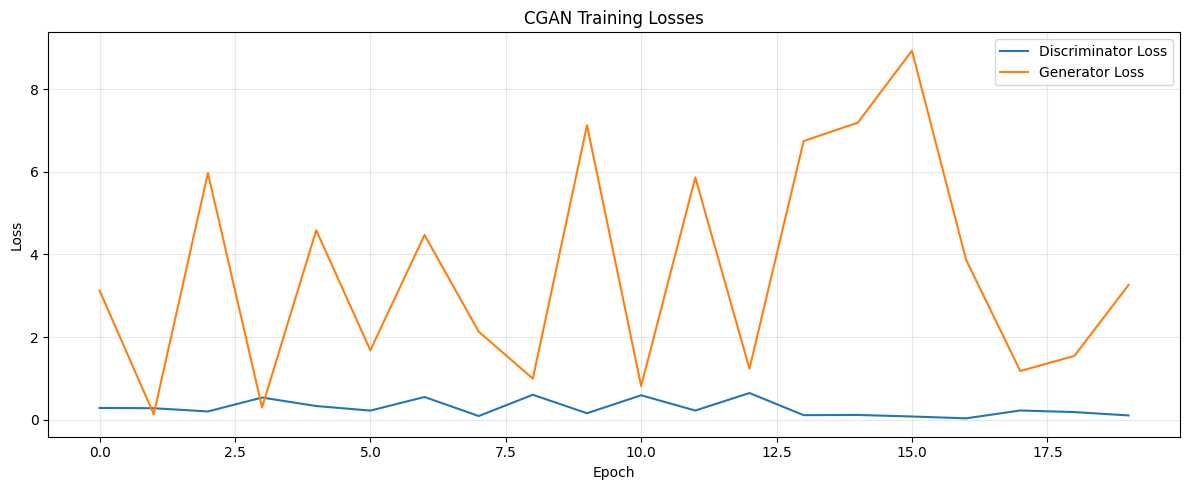

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history['d_loss'], label='Discriminator Loss')
ax.plot(history.history['g_loss'], label='Generator Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('CGAN Training Losses')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cgan_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

Healthy GAN training shows both losses converging toward ~0.69 (log(0.5)), indicating the generator and discriminator are in approximate equilibrium. If generator loss diverges upward while discriminator loss collapses to 0, the discriminator has won and the generator is not improving.

## 8. Save Generator

In [14]:
generator.save(MODELS_DIR / "cgan_generator.keras")
print("Generator saved.")

Generator saved.


## 9. Generate Balanced Synthetic Images
We compute how many images each class needs to reach the majority class count (NV: 9012) and generate only those.

In [15]:
df_train = pd.read_csv(DATA_DIR / "train_split.csv")
class_counts = df_train["class_label"].value_counts()
majority_count = class_counts.max()

needed = {}
for idx, cls in enumerate(CLASS_NAMES):
    current = class_counts.get(cls, 0)
    if current < majority_count:
        needed[idx] = majority_count - current

print("Synthetic images needed per class:")
for idx, n in needed.items():
    print(f"  {CLASS_NAMES[idx]}: {n}")

Synthetic images needed per class:
  AKIEC: 4464
  BCC: 4333
  BKL: 3924
  DF: 4612
  MEL: 3914
  VASC: 4594


In [16]:
import cv2

generated_counts = {}

for class_idx, n_generate in needed.items():
    cls_name = CLASS_NAMES[class_idx]
    cls_dir  = GENERATED_DIR / cls_name
    cls_dir.mkdir(parents=True, exist_ok=True)

    # Generate in mini-batches
    remaining = n_generate
    img_count = 0

    while remaining > 0:
        batch_n = min(64, remaining)
        noise  = tf.random.normal([batch_n, LATENT_DIM])
        labels = tf.constant([[class_idx]] * batch_n, dtype=tf.int32)

        fake_imgs = generator([noise, labels], training=False).numpy()
        fake_imgs = ((fake_imgs + 1) * 127.5).clip(0, 255).astype(np.uint8)

        for img in fake_imgs:
            out_path = cls_dir / f"syn_{img_count:05d}.jpg"
            cv2.imwrite(str(out_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            img_count += 1

        remaining -= batch_n

    generated_counts[cls_name] = img_count
    print(f"  {cls_name}: {img_count} images generated")

print("Generation complete.")

  AKIEC: 4464 images generated
  BCC: 4333 images generated
  BKL: 3924 images generated
  DF: 4612 images generated
  MEL: 3914 images generated
  VASC: 4594 images generated
Generation complete.


## 10. Visual Quality Check

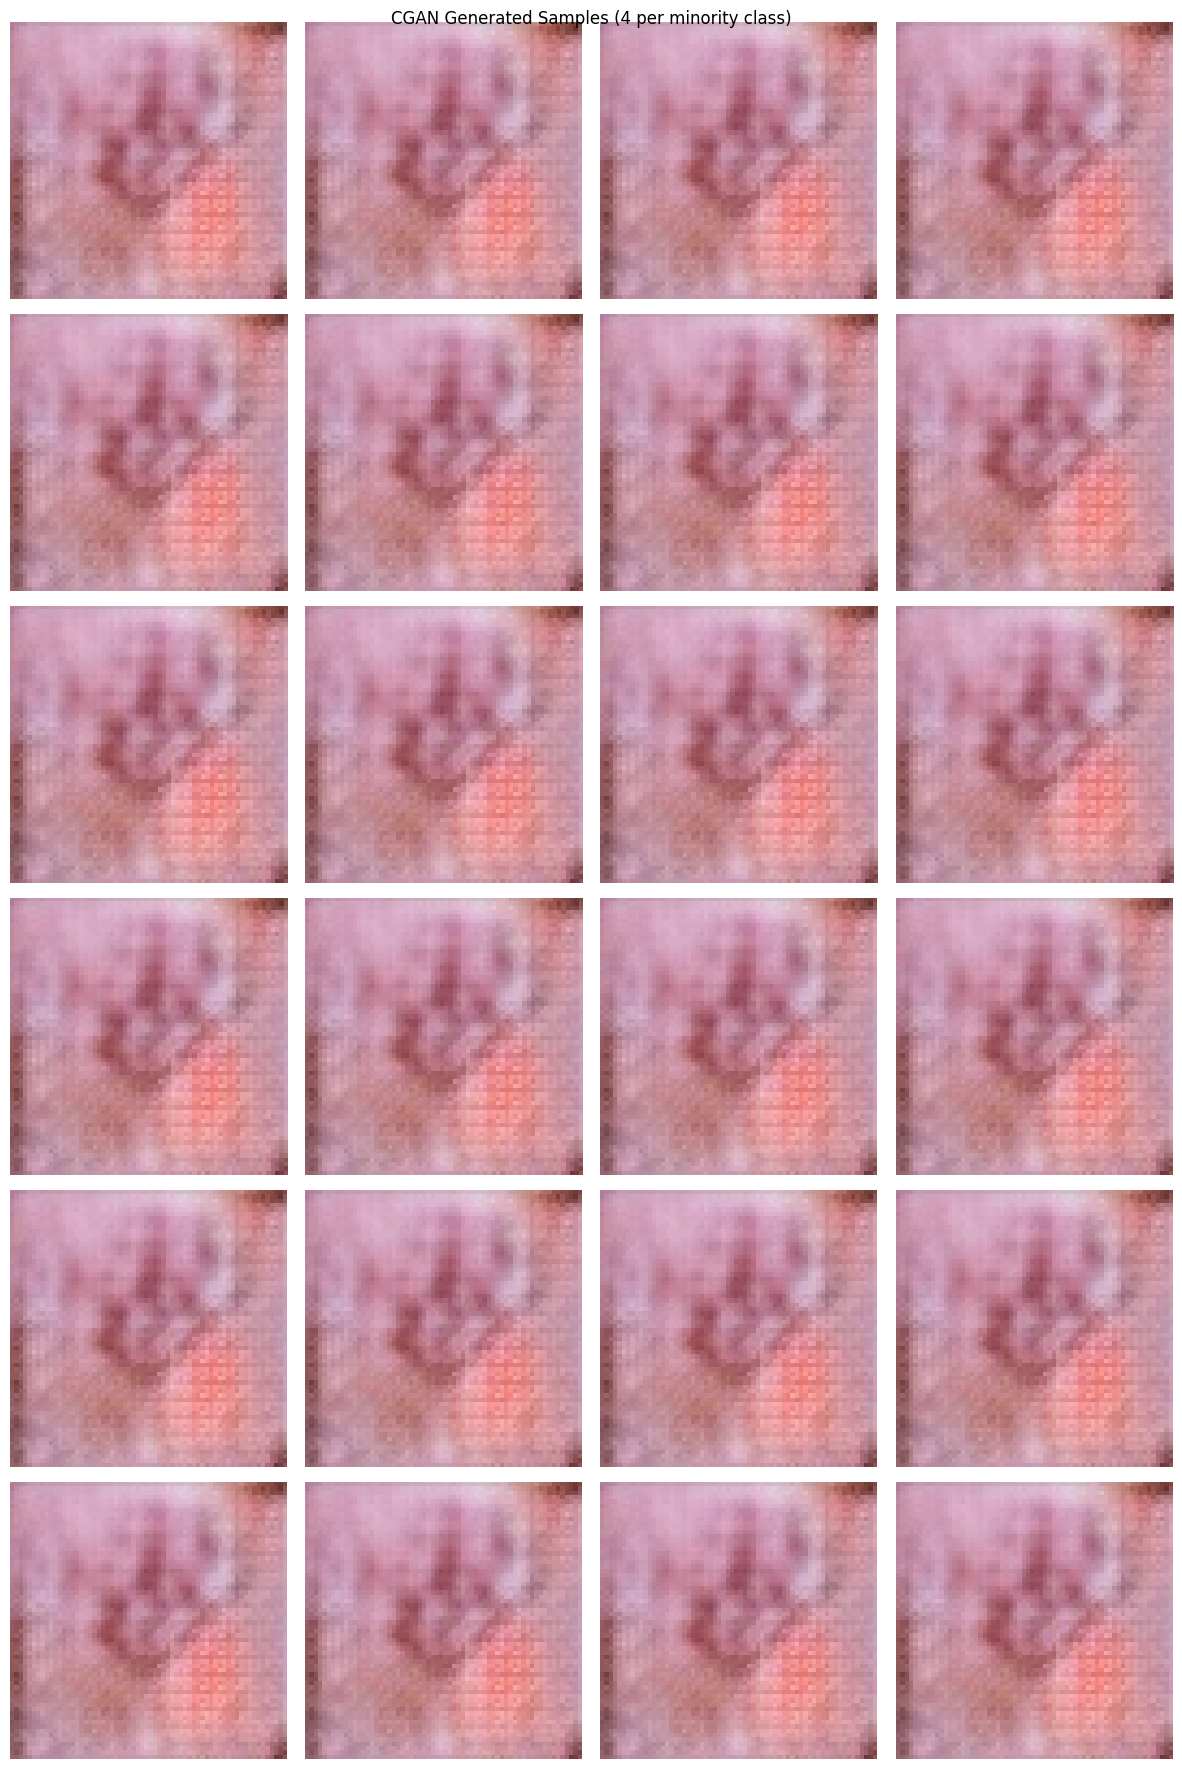

In [17]:
fig, axes = plt.subplots(len(needed), 4, figsize=(12, 3 * len(needed)))
if len(needed) == 1:
    axes = [axes]

for row_idx, (class_idx, _) in enumerate(needed.items()):
    cls_name = CLASS_NAMES[class_idx]
    cls_dir  = GENERATED_DIR / cls_name
    sample_paths = sorted(cls_dir.glob("*.jpg"))[:4]

    for col_idx, p in enumerate(sample_paths):
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx][col_idx].set_ylabel(cls_name, rotation=0, labelpad=40, va='center')

plt.suptitle("CGAN Generated Samples (4 per minority class)", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cgan_generated_samples.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
cgan_summary = {
    "model": "CGAN (Conditional GAN)",
    "img_size": IMG_SIZE,
    "latent_dim": LATENT_DIM,
    "epochs": len(history.history['d_loss']),
    "generated_per_class": generated_counts,
    "output_dir": str(GENERATED_DIR)
}

with open(RESULTS_DIR / "cgan_summary.json", "w") as f:
    json.dump(cgan_summary, f, indent=2)

print("CGAN training and generation complete.")

CGAN training and generation complete.
